In [1]:
# LAB 04A 
# TAREFA 11

In [2]:
import pandas as pd
dataset = pd.read_csv('./Galton.txt',delimiter='\t')

In [3]:
dataset.head()

,Family,Father,Mother,Gender,Height,Kids
0,1,78.5,67.0,M,73.2,4
1,1,78.5,67.0,F,69.2,4
2,1,78.5,67.0,F,69.0,4
3,1,78.5,67.0,F,69.0,4
4,2,75.5,66.5,M,73.5,4


In [4]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Father,898.0,69.232851,2.470256,62.0,68.0,69.0,71.0,78.5
Mother,898.0,64.084410,2.307025,58.0,63.0,64.0,65.5,70.5
Height,898.0,66.760690,3.582918,56.0,64.0,66.5,69.7,79.0
Kids,898.0,6.135857,2.685156,1.0,4.0,6.0,8.0,15.0


In [5]:
import seaborn as sns

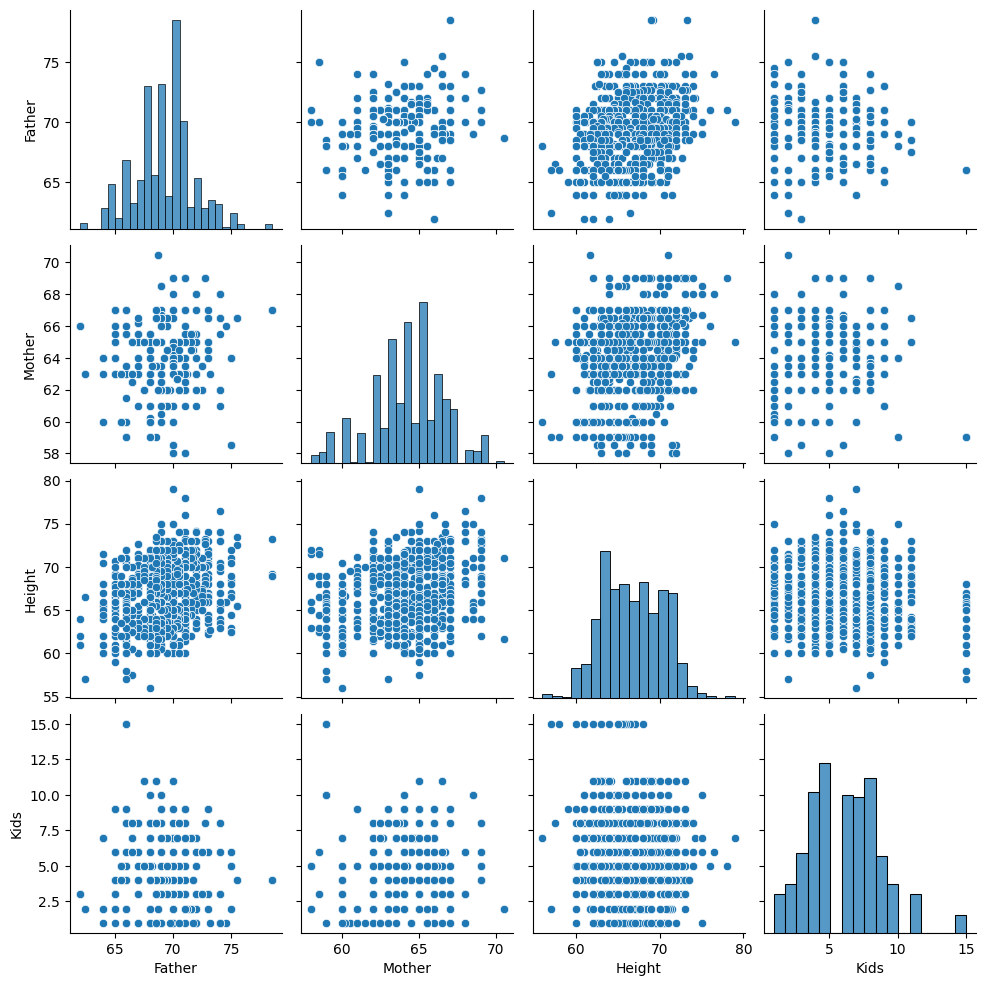

In [6]:
sns.pairplot(dataset)

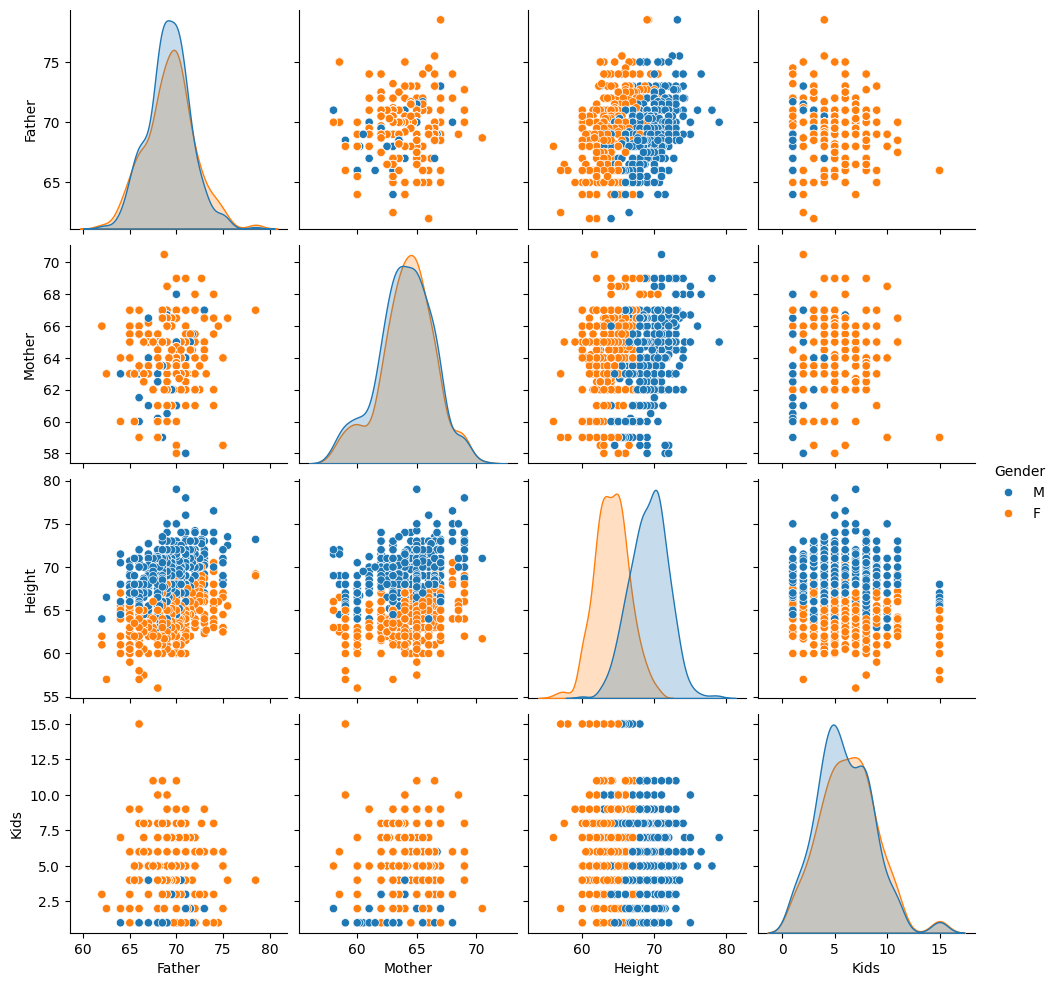

In [7]:
sns.pairplot(dataset, hue = 'Gender')

In [8]:
meninos = dataset[dataset['Gender']=='M']
meninos.info()

<class 'pandas.DataFrame'>
Index: 465 entries, 0 to 894
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Family  465 non-null    str    
 1   Father  465 non-null    float64
 2   Mother  465 non-null    float64
 3   Gender  465 non-null    str    
 4   Height  465 non-null    float64
 5   Kids    465 non-null    int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 25.4 KB


In [9]:
meninas = dataset[dataset['Gender']=='F']
meninas.info()

<class 'pandas.DataFrame'>
Index: 433 entries, 1 to 897
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Family  433 non-null    str    
 1   Father  433 non-null    float64
 2   Mother  433 non-null    float64
 3   Gender  433 non-null    str    
 4   Height  433 non-null    float64
 5   Kids    433 non-null    int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 23.7 KB


In [10]:
# Prevendo a altura das filhas (meninas)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = meninas[['Father','Mother']]
y = meninas[['Height']]
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X,y,test_size=0.2, random_state=110)
regressor = LinearRegression()
regressor.fit(X_treinamento, y_treinamento)
predicao = regressor.predict(X_teste)

In [11]:
print(regressor.intercept_)
print(regressor.coef_)

[17.53100477]
[[0.4070717  0.28776276]]


In [12]:
# Qual é a equação regressora das filhas (meninas)?
# altura das filha =

In [13]:
import numpy as np
from sklearn import metrics
print ('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, predicao))
print ('Mean Squared Error:', metrics.mean_squared_error(y_teste, predicao))
print ('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, predicao)))

Mean Absolute Error: 1.5923427908120278
Mean Squared Error: 4.102869748180961
Root Mean Squared Error: 2.025554182978318
